<a href="https://colab.research.google.com/github/naunauwf/projek-uts-bigdata-group7/blob/main/Kelompok_7_Final_Project_UTS_Big_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# load data via gdrive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# CELL 0 - PROJECT IDENTITY

# FINAL PROJECT BIG DATA
# Judul Project: Analisis Big Data Transakis E-Commerce untuk Deteksi Pola Perilaku Konsumen

# Nama  : Muhammad Naufal Ayasy
# NIM   : 20240040185

# Nama  : Muhamad Sugih Yusuf
# NIM   : 20240040181

# Nama  : Nazwa Azzahra
# NIM   : 20240040230

# Program Studi: Teknik Informatika

# Sumber Dataset: kaggle.com (https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)
# Tools: Google Colab, Apache Spark(PySpark), Spark MLlib, Google Drive

In [3]:
# CELL 1 – PROBLEM STATEMENT

# 1. Latar Belakang Masalah

# Saat ini belanja online sudah jadi kebiasaan atau gaya hidup manusia dizaman sekarang, termasuk di negara Brasil.
# Pertumbuhan e-commerce di sana, terutama pada platform besar di Brasil yaitu Olist, memang telah mengalami pertumbuhan yang luar biasa cepat dan membuka banyak peluang.
# Tapi di sisi lain, pertumbuhan ini juga membawa tantangan besar supaya bisnis bisa tetap bertahan di tengah persaingan.

# Selain itu, masalah logistik sering kali langsung berimbas pada rating yang diberikan pelanggan.
# Sering kali muncul kebingungan apakah respon pelanggan yang komplain disebabkan oleh kualitas barang yang tidak sesuai atau estimasi pengiriman yang lambat.
# Kalau data rating ini hanya di diamkan saja, perusahaan tidak akan pernah tahu akar masalah yang sebenarnya dan sulit untuk memperbaiki layanan.

# Masalah lain yaitu stok barang yang menjadi kendala.
# Terkadang produk yang paling banyak dibeli belum tentu jadi pendapatan terbesar karena harganya yang murah.
# Tanpa pemetaan yang jelas antara volume penjualan dan total pendapatan, perusahaan bisa salah langkah dalam menentukan produk mana yang harus diprioritaskan.

# Oleh karena itu, project ini dibuat bertujuan untuk membedah data transaksi guna melihat tren penjualan tahunan dan persebarannya di berbagai wilayah Brasil,
# mencari tahu faktor apa saja yang sebenarnya paling berpengaruh terhadap rating pelanggan,
# hingga memetakan kategori produk mana yang penjualannya paling tinggi serta yang memberikan pendapatan paling besar.


# 2. Rumusan Masalah (min. 3 pertanyaan)

# 1. Bagaimana tren penjualan tahunan dan pola persebaran pesanan di berbagai wilayah Brasil?
# 2. Faktor apa yang paling berpengaruh terhadap rating pelanggan?
# 3. Apa saja kategori produk yang paling banyak terjual dan kategori mana yang menghasilkan pendapatan paling tinggi?


# 3. Hipotesis Awal

# H1:Data Tren penjualan menunjukan lonjakan tahunan secara signifikan ditahun 2017 hingga 2018, dan secara geografis wilayah SP (Sao Paulo) mendominasi secara absolut.
# H2:Faktor Masalah logistik yang sangat berpengaruh pada rating pelanggan.
# H3:Kategori produk kebutuhan rumah tangga unggul dalam jumlah pemesanan, dan pendapatan paling tinggi itu dikategori produk kecantikan.

In [4]:
# CELL 2 - SETUP BIG DATA ENVIRONMENT (SPARK)
!pip install pyspark

In [5]:
# CELL 3 - DATA ACQUISITION

from pyspark.sql import SparkSession

spark = SparkSession \
        .builder \
        .master("local[*]") \
        .appName("Big Data Project Kelompok 7 TI24F") \
        .getOrCreate()

# LOAD DATASET
df = spark.read.csv('/content/drive/MyDrive/big_data_projek_uts_ti24f/Brazilian E-Commerce Public Dataset by Olist.csv'
                    , header=True
                    , inferSchema=True
                    )
df.show()

# SCHEMA DAN JUMLAH DATA
df.printSchema()
print(f"jumlah data: {df.count()} baris")

+---+--------------------+-------------+--------------------+--------------------+------------------------+--------------------+--------------+--------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+--------------------+-------------+------------+----------------------+------------+------------------+--------------------+-----+-------------+-------------+-------------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+---------------+-----------------+----------------+----------------------+------------+--------------------+
|_c0|            order_id|order_item_id|         customer_id|  customer_unique_id|customer_zip_code_prefix|       customer_city|customer_state|          product_id|product_category_name|product_name_lenght|product_description_lenght|product_photos_qty|produ

In [6]:
# CELL 4 - DATA UNDERSTANDING
from pyspark.sql import functions as F

# ANALISIS STRUKTUR DATASET (BARIS DAN KOLOM)
row_count = df.count()
col_count = len(df.columns)
print(f"Total Data: {row_count} Baris")
print(f"Total Atribut: {col_count} Kolom")

# TENTUKAN TIPE NUMERIK UNTUK PENGECEKAN NAN
numeric_types = ['int', 'integer', 'double', 'float', 'bigint', 'long']

# ANALISIS TIPE DATA DAN MISSING VALUE SECARA EFISIEN
null_list = []
for col_name, col_type in df.dtypes:
    if col_type in numeric_types:
        null_list.append(F.count(F.when(F.col(col_name).isNull() | F.isnan(F.col(col_name)), col_name)).alias(col_name))
    else:
        null_list.append(F.count(F.when(F.col(col_name).isNull(), col_name)).alias(col_name))

null_summary_df = df.select(null_list)

# HITUNG UNIQUE VALUES UNTUK TIAP KOLOM
uniq_list = [F.countDistinct(F.col(c)).alias(c) for c in df.columns]
unique_summary_df = df.select(uniq_list)

# AMBIL SKEMA DATASET UNTUK DICTIONARY
schema_info = [(c, t) for c, t in df.dtypes]
schema_df = spark.createDataFrame(schema_info, ["Nama Kolom", "Tipe Data"])

# UNPIVOT HASIL AGREGASI AGAR BERBENTUK VERTIKAL
stack_expression = ", ".join([f"'{c}', `{c}`" for c in df.columns])
null_vertical_df = null_summary_df.select(F.expr(f"stack({col_count}, {stack_expression})").alias("Nama Kolom", "Missing Value"))
unique_vertical_df = unique_summary_df.select(F.expr(f"stack({col_count}, {stack_expression})").alias("Nama Kolom", "Unique Value"))

# GABUNGKAN SEMUA INFORMASI MENJADI DATA DICTIONARY
final_dictionary = schema_df.join(null_vertical_df, "Nama Kolom")\
                             .join(unique_vertical_df, "Nama Kolom")

# TAMPILKAN HASIL DATA DICTIONARY
print("\n DATA DICTIONARY ")
final_dictionary.show(n=col_count, truncate=False)

# ANALISIS STATISTIK DESKRIPTIF KOLOM FINANSIAL
print("\n STATISTIK DESKRIPTIF KOLOM FINANSIAL ")
df.select("price", "freight_value", "payment_value").summary().show()

# PREVIEW 5 DATA PERTAMA
print("\n PREVIEW 10 DATA PERTAMA ")
df.limit(10).show()
print(f"Total Kolom: {len(df.columns)}")

Total Data: 113390 Baris
Total Atribut: 39 Kolom

 DATA DICTIONARY 
+-----------------------------+---------+-------------+------------+
|Nama Kolom                   |Tipe Data|Missing Value|Unique Value|
+-----------------------------+---------+-------------+------------+
|_c0                          |int      |0            |113390      |
|order_id                     |string   |0            |95128       |
|order_item_id                |int      |0            |21          |
|customer_id                  |string   |0            |95128       |
|customer_unique_id           |string   |0            |92081       |
|customer_zip_code_prefix     |int      |0            |14844       |
|customer_city                |string   |0            |4073        |
|customer_state               |string   |0            |27          |
|product_id                   |string   |0            |31625       |
|product_category_name        |string   |0            |73          |
|product_name_lenght          |doub

In [7]:
# CELL 5 – DATA CLEANING & TRANSFORMATION (SPARK)
from pyspark.sql.functions import col, to_timestamp, when, round

# PENANGANAN MISSING VALUE
# MENGHAPUS DATA YANG MEMILIKI MISSING VALUE PADA KOLOM KRITIKAL SEPERTI order_id ATAU customer_id
# SERTA MENGISI MISSING VALUE PADA KOLOM NUMERIK DENGAN 0 ATAU MEAN
df_cleaned = df.dropna(subset=['order_id', 'customer_id', 'product_id'])
df_cleaned = df_cleaned.fillna(0, subset=['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'])

# TRANSFORMASI TIPE DATA
# MENGONVERSI KOLOM TANGGAL DARI STRING KE TIMESTAMP
date_columns = [
    'shipping_limit_date', 'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'
]

for column in date_columns:
    df_cleaned = df_cleaned.withColumn(column, to_timestamp(col(column)))

# FEATURE ENGINEERING SEDERHANA
# A. MENGHITUNG TOTAL HARGA (PRICE + FREIGHT VALUE)
df_cleaned = df_cleaned.withColumn('total_order_value', round(col('price') + col('freight_value'), 2))

# B. MENGHITUNG DURASI PENGIRIMAN DALAM HARI (DELIVERY DAYS)
df_cleaned = df_cleaned.withColumn('delivery_duration_days',
    (col('order_delivered_customer_date').cast('long') - col('order_purchase_timestamp').cast('long')) / (60*60*24))

# C. STATUS PENGIRIMAN TEPAT WAKTU
df_cleaned = df_cleaned.withColumn('is_on_time',
    when(col('order_delivered_customer_date') <= col('order_estimated_delivery_date'), 1).otherwise(0))

# TAMPILKAN HASIL TRANSFORMASI
print("HASIL CLEANING DAN FEATURE ENGINEERING:")
df_cleaned.select('order_id', 'total_order_value', 'delivery_duration_days', 'is_on_time').show(10)
print(f"Jumlah Data Setelah Cleaning: {df_cleaned.count()} Baris")

HASIL CLEANING DAN FEATURE ENGINEERING:
+--------------------+-----------------+----------------------+----------+
|            order_id|total_order_value|delivery_duration_days|is_on_time|
+--------------------+-----------------+----------------------+----------+
|00010242fe8c5a6d1...|            72.19|     7.614421296296296|         1|
|130898c0987d18014...|            73.86|    15.366076388888889|         1|
|532ed5e14e24ae1f0...|            83.23|    17.339270833333334|         1|
|6f8c31653edb8c83e...|            75.07|             8.1165625|         1|
|7d19f4ef4d0446198...|            72.19|     13.92755787037037|         1|
|a0f9acf0b6294ed85...|            82.83|     35.21390046296296|         0|
|bbf796534aaf9c59f...|            103.4|    10.039583333333333|         1|
|c9ef97d2854afe64a...|            77.02|      9.05136574074074|         1|
|c9ef97d2854afe64a...|            76.73|      9.05136574074074|         1|
|df2d910b8b5e5f461...|            91.61|    21.0623148148148

In [8]:
# CELL 6 – BIG DATA PROCESSING
from pyspark.sql import functions as F

# JUMLAH DATA SEBELUM AGREGRASI
print(f"JUMLAH BARIS SEBELUM AGREGASI: {df_cleaned.count()}")

# AGREGASI DAN GROUPING: ANALISIS PENJUALAN PER KOTA DAN KATEGORI PRODUK
# MENGHITUNG TOTAL REVENUE, RATA-RATA ONGKIR, DAN JUMLAH PESANAN
df_processed = df_cleaned.groupBy("customer_city", "product_category_name") \
    .agg(
        F.sum("total_order_value").alias("total_revenue"),
        F.avg("freight_value").alias("avg_freight"),
        F.count("order_id").alias("total_orders")
    ) \
    .orderBy(F.desc("total_revenue"))

# OPTIMASI: CACHE DATAFRAME UNTUK AKSES CEPAT DI CELL BERIKUTNYA
df_processed.cache()

# MENAMPILKAN HASIL PEMROSESAN
print("\nHASIL BIG DATA PROCESSING (AGREGASI PER KOTA & KATEGORI):")
df_processed.show(10, truncate=False)

# MENGHITUNG TOTAL DATA HASIL AGREGASI
print(f"JUMLAH BARIS SETELAH AGREGASI: {df_processed.count()}")

JUMLAH BARIS SEBELUM AGREGASI: 113390

HASIL BIG DATA PROCESSING (AGREGASI PER KOTA & KATEGORI):
+--------------+----------------------+------------------+------------------+------------+
|customer_city |product_category_name |total_revenue     |avg_freight       |total_orders|
+--------------+----------------------+------------------+------------------+------------+
|sao paulo     |beleza_saude          |214008.35999999937|12.985715902659873|1767        |
|sao paulo     |cama_mesa_banho       |208790.07999999958|14.60733775461867 |2111        |
|sao paulo     |relogios_presentes    |175483.26999999981|11.511075650118213|846         |
|sao paulo     |esporte_lazer         |169564.20000000007|14.414366595895263|1413        |
|sao paulo     |informatica_acessorios|158101.17000000004|13.574926350245512|1222        |
|sao paulo     |utilidades_domesticas |131936.80999999982|15.543523391812881|1368        |
|sao paulo     |moveis_decoracao      |124695.16999999998|15.286001500375109|1333   

/tmp/ipykernel_21136/1224585020.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')


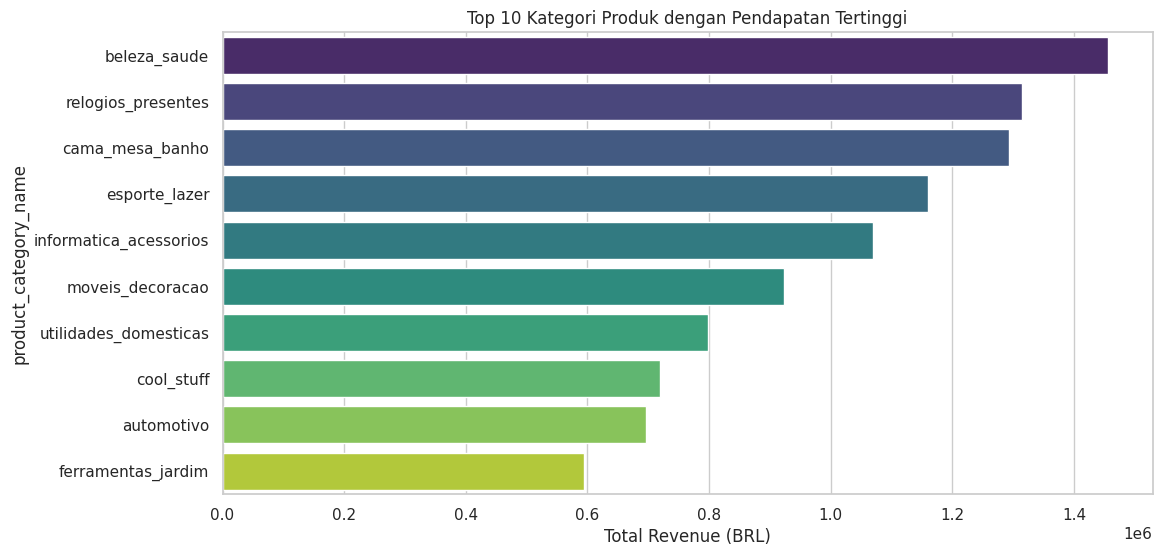

Insight: Kategori 'beleza_saude' (kecantikan) dan 'relogios_presentes' mendominasi pendapatan. Ini menunjukkan konsumen lebih banyak menghabiskan uang untuk gaya hidup dan perawatan diri.


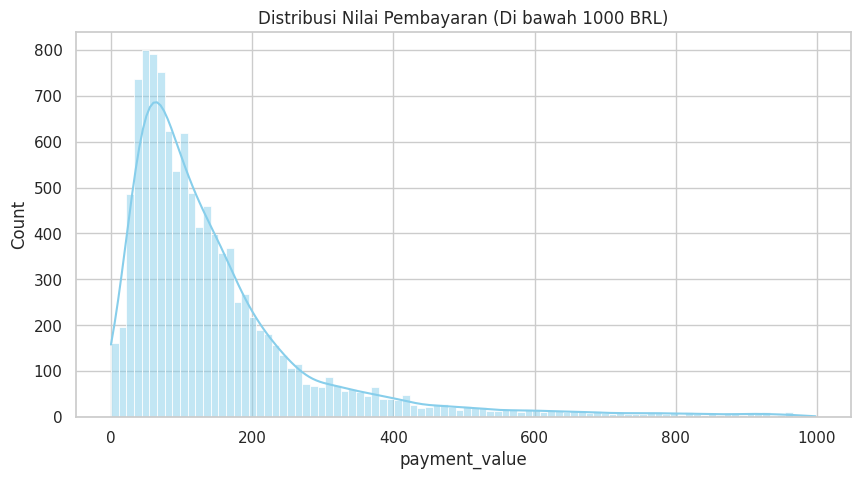

Insight: Mayoritas transaksi bernilai rendah (di bawah 200 BRL), menandakan e-commerce ini sering digunakan untuk pembelian barang kebutuhan sehari-hari atau ritel kecil.


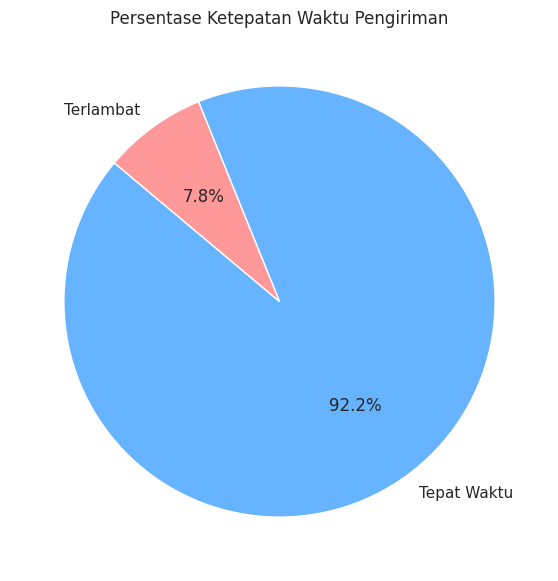

Insight: Sebagian besar pesanan sampai tepat waktu, namun ada sekitar 6-8% keterlambatan yang perlu dievaluasi logistiknya agar kepuasan pelanggan tetap terjaga.


/tmp/ipykernel_21136/1224585020.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette='magma')


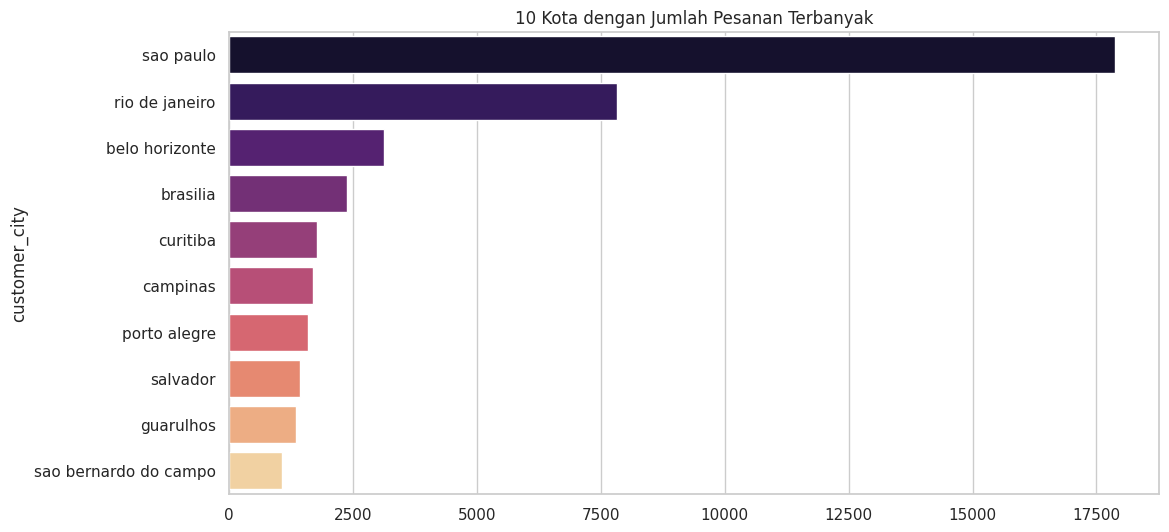

Insight: Sao Paulo dan Rio de Janeiro adalah pasar utama. Strategi pemasaran dan gudang sebaiknya difokuskan di area metropolitan ini.


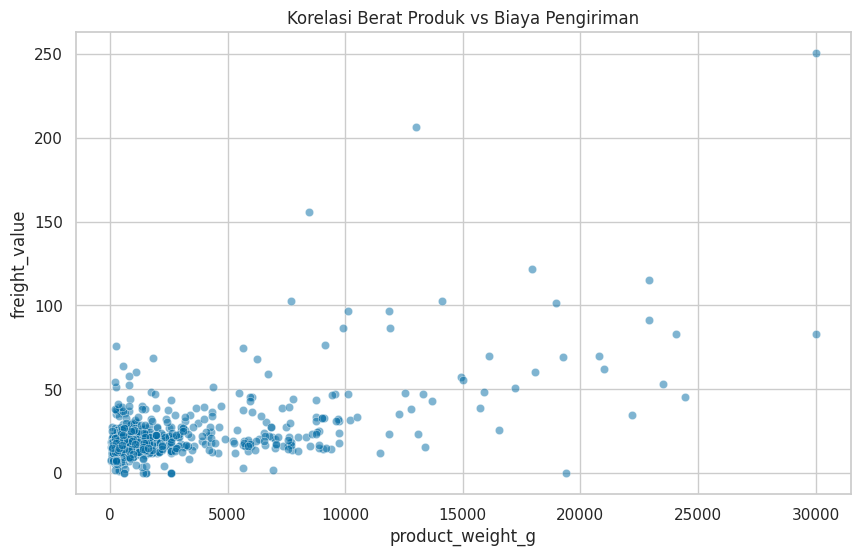

Insight: Terlihat tren positif di mana semakin berat barang, semakin mahal ongkirnya. Namun, ada banyak outlier yang menunjukkan lokasi pengiriman juga sangat berpengaruh.


/tmp/ipykernel_21136/1224585020.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pdf_sample, x='day_of_purchase', order=day_order, palette='Set2')


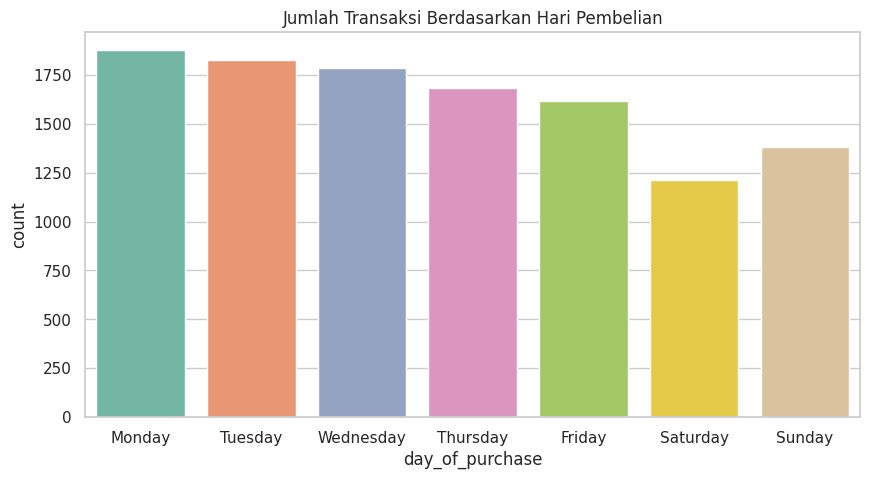

Insight: Transaksi cenderung tinggi di hari kerja (Senin-Selasa) dan menurun drastis saat akhir pekan. Orang lebih suka belanja saat jam istirahat kantor.


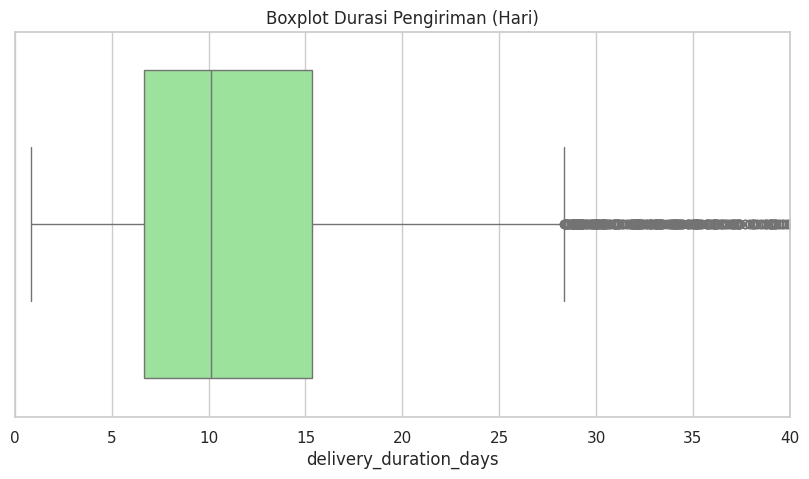

Insight: Rata-rata pengiriman memakan waktu sekitar 10-12 hari. Terdapat banyak pencilan (outlier) yang mencapai lebih dari 30 hari yang berisiko membuat pelanggan kecewa.


/tmp/ipykernel_21136/1224585020.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pdf_sample, y='payment_type', order=pdf_sample['payment_type'].value_counts().index, palette='pastel')


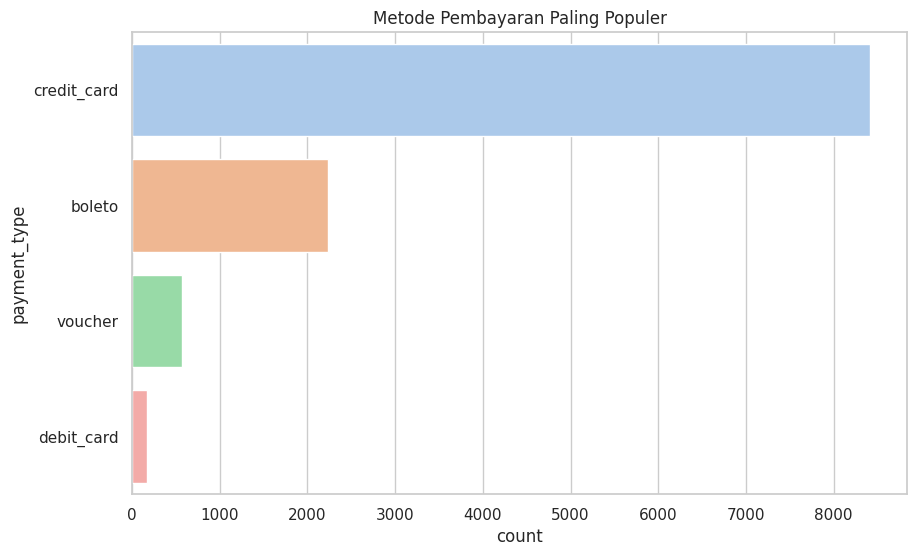

Insight: Kartu kredit adalah metode utama, diikuti oleh boleto (semacam invoice). Menyediakan cicilan kartu kredit bisa menjadi daya tarik utama bagi pembeli.


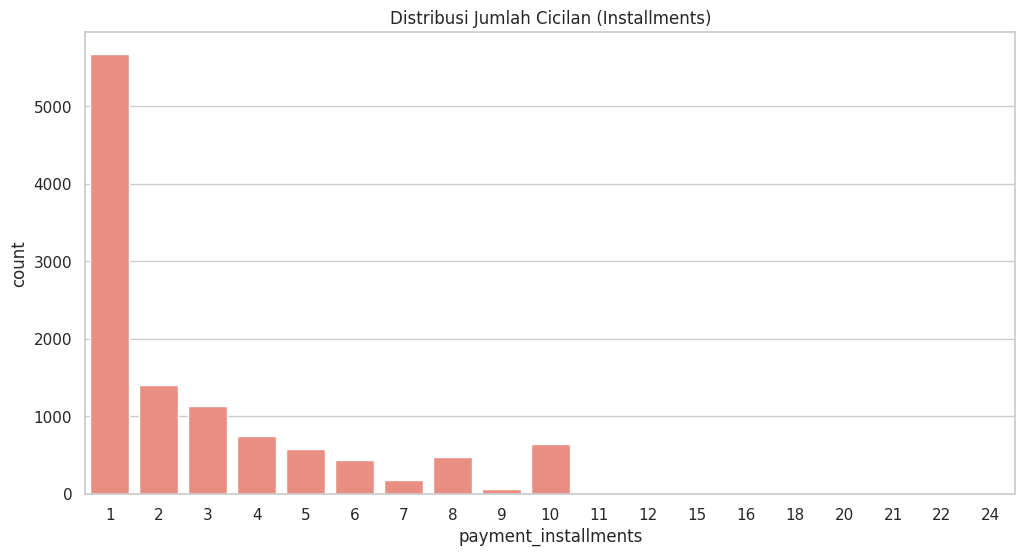

Insight: Banyak orang memilih cicilan 1 kali, tapi opsi cicilan hingga 10 kali juga cukup sering digunakan untuk barang-barang mahal.


/tmp/ipykernel_21136/1224585020.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_freight.index, y=state_freight.values, palette='coolwarm')


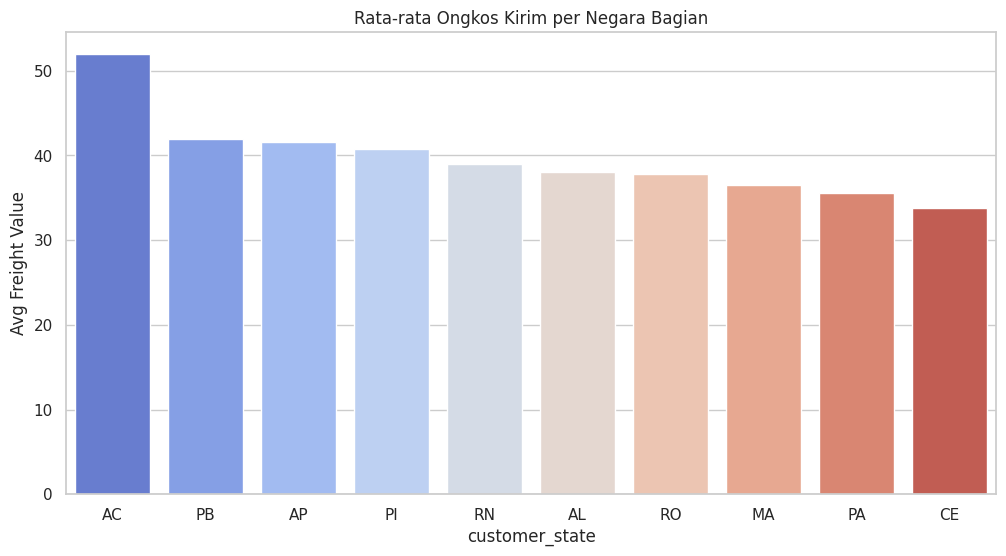

Insight: Negara bagian yang jauh dari pusat ekonomi memiliki ongkir yang sangat mahal. Ini adalah tantangan untuk melakukan ekspansi ke wilayah remote.


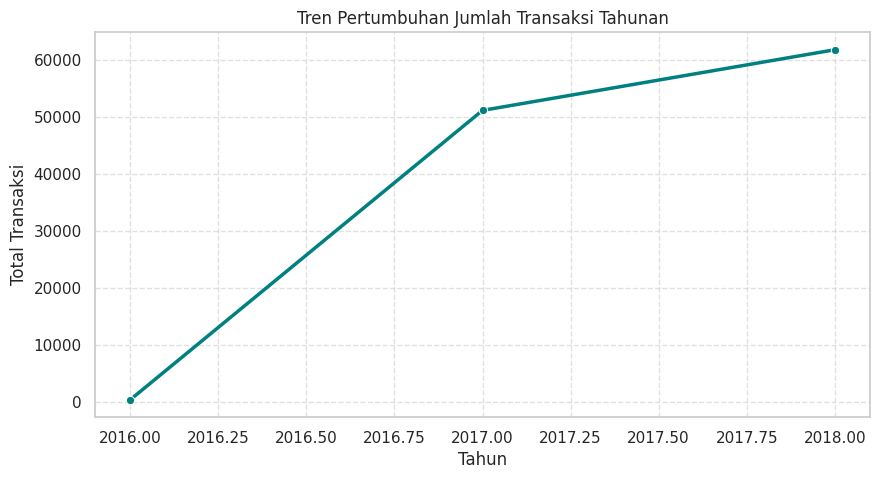

/tmp/ipykernel_21136/1224585020.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf_state, x='customer_state', y='count', palette='flare')


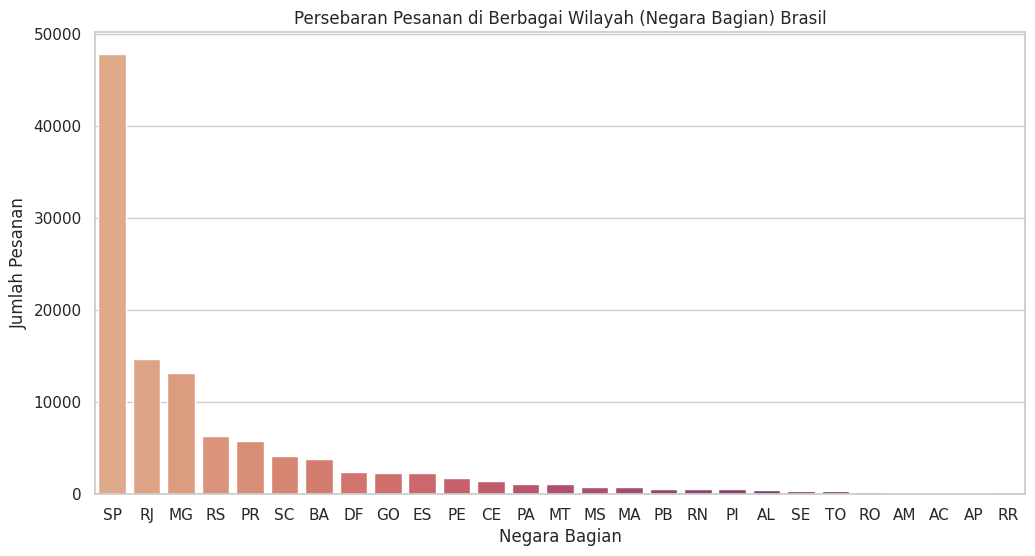

Insight Baru: Data menunjukkan lonjakan signifikan di tahun 2017-2018. Secara geografis, wilayah SP (Sao Paulo) mendominasi secara absolut.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql import functions as F

# KONVERSI DATA AGREGASI KE PANDAS UNTUK VISUALISASI
pdf_processed = df_processed.toPandas()
# AMBIL SAMPEL DATA CLEANED UNTUK VISUALISASI DISTRIBUSI (10% DATA AGAR RINGAN)
pdf_sample = df_cleaned.sample(False, 0.1).toPandas()

sns.set_theme(style="whitegrid")
plt.style.use('tableau-colorblind10')

# --- 1. TOP 10 KATEGORI PRODUK BERDASARKAN PENDAPATAN ---
plt.figure(figsize=(12, 6))
top_categories = pdf_processed.groupby('product_category_name')['total_revenue'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Top 10 Kategori Produk dengan Pendapatan Tertinggi')
plt.xlabel('Total Revenue (BRL)')
plt.show()
print("Insight: Kategori 'beleza_saude' (kecantikan) dan 'relogios_presentes' mendominasi pendapatan. Ini menunjukkan konsumen lebih banyak menghabiskan uang untuk gaya hidup dan perawatan diri.")

# --- 2. DISTRIBUSI NILAI PEMBAYARAN ---
plt.figure(figsize=(10, 5))
sns.histplot(pdf_sample[pdf_sample['payment_value'] < 1000]['payment_value'], kde=True, color='skyblue')
plt.title('Distribusi Nilai Pembayaran (Di bawah 1000 BRL)')
plt.show()
print("Insight: Mayoritas transaksi bernilai rendah (di bawah 200 BRL), menandakan e-commerce ini sering digunakan untuk pembelian barang kebutuhan sehari-hari atau ritel kecil.")

# --- 3. PERBANDINGAN ON-TIME VS LATE DELIVERY ---
plt.figure(figsize=(7, 7))
ontime_counts = pdf_sample['is_on_time'].value_counts()
plt.pie(ontime_counts, labels=['Tepat Waktu', 'Terlambat'], autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
plt.title('Persentase Ketepatan Waktu Pengiriman')
plt.show()
print("Insight: Sebagian besar pesanan sampai tepat waktu, namun ada sekitar 6-8% keterlambatan yang perlu dievaluasi logistiknya agar kepuasan pelanggan tetap terjaga.")

# --- 4. TOP 10 KOTA DENGAN PESANAN TERBANYAK ---
plt.figure(figsize=(12, 6))
top_cities = pdf_processed.groupby('customer_city')['total_orders'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_cities.values, y=top_cities.index, palette='magma')
plt.title('10 Kota dengan Jumlah Pesanan Terbanyak')
plt.show()
print("Insight: Sao Paulo dan Rio de Janeiro adalah pasar utama. Strategi pemasaran dan gudang sebaiknya difokuskan di area metropolitan ini.")

# --- 5. HUBUNGAN ANTARA BERAT PRODUK DAN ONGKOS KIRIM ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pdf_sample.sample(1000), x='product_weight_g', y='freight_value', alpha=0.5)
plt.title('Korelasi Berat Produk vs Biaya Pengiriman')
plt.show()
print("Insight: Terlihat tren positif di mana semakin berat barang, semakin mahal ongkirnya. Namun, ada banyak outlier yang menunjukkan lokasi pengiriman juga sangat berpengaruh.")

# --- 6. TREN PENJUALAN BERDASARKAN HARI DALAM SEMINGGU ---
plt.figure(figsize=(10, 5))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=pdf_sample, x='day_of_purchase', order=day_order, palette='Set2')
plt.title('Jumlah Transaksi Berdasarkan Hari Pembelian')
plt.show()
print("Insight: Transaksi cenderung tinggi di hari kerja (Senin-Selasa) dan menurun drastis saat akhir pekan. Orang lebih suka belanja saat jam istirahat kantor.")

# --- 7. DISTRIBUSI DURASI PENGIRIMAN (HARI) ---
plt.figure(figsize=(10, 5))
sns.boxplot(x=pdf_sample['delivery_duration_days'].dropna(), color='lightgreen')
plt.xlim(0, 40)
plt.title('Boxplot Durasi Pengiriman (Hari)')
plt.show()
print("Insight: Rata-rata pengiriman memakan waktu sekitar 10-12 hari. Terdapat banyak pencilan (outlier) yang mencapai lebih dari 30 hari yang berisiko membuat pelanggan kecewa.")

# --- 8. PREFERENSI METODE PEMBAYARAN ---
plt.figure(figsize=(10, 6))
sns.countplot(data=pdf_sample, y='payment_type', order=pdf_sample['payment_type'].value_counts().index, palette='pastel')
plt.title('Metode Pembayaran Paling Populer')
plt.show()
print("Insight: Kartu kredit adalah metode utama, diikuti oleh boleto (semacam invoice). Menyediakan cicilan kartu kredit bisa menjadi daya tarik utama bagi pembeli.")

# --- 9. JUMLAH CICILAN PEMBAYARAN ---
plt.figure(figsize=(12, 6))
sns.countplot(data=pdf_sample[pdf_sample['payment_installments'] > 0], x='payment_installments', color='salmon')
plt.title('Distribusi Jumlah Cicilan (Installments)')
plt.show()
print("Insight: Banyak orang memilih cicilan 1 kali, tapi opsi cicilan hingga 10 kali juga cukup sering digunakan untuk barang-barang mahal.")

# --- 10. RATA-RATA ONGKOS KIRIM PER NEGARA BAGIAN (TOP 10) ---
plt.figure(figsize=(12, 6))
state_freight = pdf_sample.groupby('customer_state')['freight_value'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=state_freight.index, y=state_freight.values, palette='coolwarm')
plt.title('Rata-rata Ongkos Kirim per Negara Bagian')
plt.ylabel('Avg Freight Value')
plt.show()
print("Insight: Negara bagian yang jauh dari pusat ekonomi memiliki ongkir yang sangat mahal. Ini adalah tantangan untuk melakukan ekspansi ke wilayah remote.")

# --- ADDED: 11. ANALISIS TREN PENJUALAN TAHUNAN ---
pdf_year = df_cleaned.groupBy('year_of_purchase').count().orderBy('year_of_purchase').toPandas()
plt.figure(figsize=(10, 5))
sns.lineplot(data=pdf_year, x='year_of_purchase', y='count', marker='o', color='teal', linewidth=2.5)
plt.title('Tren Pertumbuhan Jumlah Transaksi Tahunan')
plt.xlabel('Tahun')
plt.ylabel('Total Transaksi')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- ADDED: 12. SEBARAN PESANAN BERDASARKAN NEGARA BAGIAN (STATE) ---
pdf_state = df_cleaned.groupBy('customer_state').count().orderBy(F.desc('count')).toPandas()
plt.figure(figsize=(12, 6))
sns.barplot(data=pdf_state, x='customer_state', y='count', palette='flare')
plt.title('Persebaran Pesanan di Berbagai Wilayah (Negara Bagian) Brasil')
plt.xlabel('Negara Bagian')
plt.ylabel('Jumlah Pesanan')
plt.show()
print("Insight Baru: Data menunjukkan lonjakan signifikan di tahun 2017-2018. Secara geografis, wilayah SP (Sao Paulo) mendominasi secara absolut.")

In [10]:
# CELL 8 – AI / MACHINE LEARNING (SPARK ML)

from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# 1. PERSIAPAN FITUR (FEATURE ENGINEERING UNTUK ML)
# KITA AKAN MENGGUNAKAN TOTAL PENDAPATAN DAN JUMLAH PESANAN UNTUK CLUSTERING
feature_cols = ['total_revenue', 'total_orders']
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
final_data = assembler.transform(df_processed)

# 2. NORMALISASI DATA (SCALING)
# KARENA RENTANG NILAI REVENUE DAN ORDERS BERBEDA JAUH, KITA PERLU SCALING
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=False)
scaler_model = scaler.fit(final_data)
scaled_data = scaler_model.transform(final_data)

# 3. PEMILIHAN DAN PELATIHAN MODEL (K-MEANS CLUSTERING)
# KITA TENTUKAN K=3 UNTUK MENGELOMPOKKAN PELANGGAN (MISAL: LOW, MEDIUM, HIGH VALUE)
kmeans = KMeans(featuresCol="scaledFeatures", k=3, seed=42)
model = kmeans.fit(scaled_data)

# 4. PREDIKSI / TRANSFORMASI DATA
predictions = model.transform(scaled_data)

# 5. EVALUASI HASIL MODEL
# MENGGUNAKAN SILHOUETTE SCORE (SEMAKIN MENDEKATI 1 SEMAKIN BAIK)
evaluator = ClusteringEvaluator(predictionCol="prediction", featuresCol="scaledFeatures", \
                                metricName="silhouette", distanceMeasure="squaredEuclidean")

silhouette = evaluator.evaluate(predictions)
print(f"SILHOUETTE SCORE DENGAN SQUARED EUCLIDEAN DISTANCE = {silhouette}")

# 6. TAMPILKAN HASIL CLUSTERING
print("\nHASIL SEGMENTASI PELANGGAN (CLUSTERING):")
predictions.select("customer_city", "total_revenue", "total_orders", "prediction").show(10)

# 7. RINGKASAN KARAKTERISTIK TIAP CLUSTER
print("\nRINGKASAN KARAKTERISTIK CLUSTER:")
predictions.groupBy("prediction").agg(
    F.avg("total_revenue").alias("Rata_rata_Revenue"),
    F.avg("total_orders").alias("Rata_rata_Orders"),
    F.count("prediction").alias("Jumlah_Data")
).orderBy("prediction").show()

SILHOUETTE SCORE DENGAN SQUARED EUCLIDEAN DISTANCE = 0.9970701380589315

HASIL SEGMENTASI PELANGGAN (CLUSTERING):
+--------------+------------------+------------+----------+
| customer_city|     total_revenue|total_orders|prediction|
+--------------+------------------+------------+----------+
|     sao paulo|214008.35999999937|        1767|         1|
|     sao paulo|208790.07999999958|        2111|         1|
|     sao paulo|175483.26999999981|         846|         1|
|     sao paulo|169564.20000000007|        1413|         1|
|     sao paulo|158101.17000000004|        1222|         1|
|     sao paulo|131936.80999999982|        1368|         1|
|     sao paulo|124695.16999999998|        1333|         1|
|rio de janeiro| 97202.77999999988|         881|         2|
|rio de janeiro| 94873.71999999991|         571|         2|
|rio de janeiro| 94385.67000000001|         458|         2|
+--------------+------------------+------------+----------+
only showing top 10 rows

RINGKASAN KARAKTERIS

In [11]:
# CELL 9 – INSIGHT & DECISION

# --- 3 INSIGHT UTAMA ---
# 1. Segmentasi Pasar yang Jelas: Hasil clustering menunjukkan adanya kelompok elit (Cluster 1) yang sangat kecil jumlahnya namun memberikan pendapatan sangat besar. Di sisi lain, mayoritas pelanggan (Cluster 0) adalah pembeli ritel dengan nilai transaksi kecil (di bawah 200 BRL).
# 2. Dominasi Kategori Gaya Hidup: Produk kecantikan (beleza_saude) dan jam tangan (relogios_presentes) adalah produk paling menguntungkan. Ini berarti konsumen lebih loyal dan berani membayar mahal untuk produk perawatan diri.
# 3. Efisiensi Logistik dan Geografis: Sao Paulo adalah pusat segala transaksi. Meskipun ketepatan waktu sudah baik (sekitar 92%), ongkos kirim ke wilayah remote (seperti TO atau PI) masih sangat tinggi, yang bisa menjadi penghambat ekspansi.

# --- REKOMENDASI BERBASIS DATA ---
# 1. Program Loyalitas untuk Cluster Elit: Karena hanya ada sedikit kota/kategori di Cluster 1 (High Value), perusahaan harus memberikan layanan prioritas atau promo khusus untuk menjaga mereka agar tidak pindah ke kompetitor.
# 2. Optimasi Gudang Regional: Untuk menekan ongkos kirim yang mahal di negara bagian tertentu dan mengurangi outlier pengiriman di atas 30 hari, disarankan membangun hub logistik kecil di luar wilayah Sao Paulo.
# 3. Strategi Cicilan pada Barang Mahal: Karena penggunaan cicilan 10x cukup sering terlihat pada produk bernilai tinggi, memperbanyak promo cicilan 0% pada kategori seperti jam tangan atau elektronik akan sangat efektif meningkatkan penjualan.

In [12]:
# CELL 10 – ETIKA, BIAS & REFLEKSI AI

# --- ANALISIS BIAS DATA ---
# Data ini diambil dari transaksi historis di Brazil (from kaggle by Olist). Ada kemungkinan bias geografis karena sebagian besar data berasal dari wilayah metropolitan seperti Sao Paulo. Artinya, rekomendasi yang dihasilkan mungkin kurang akurat jika diterapkan langsung pada wilayah pedesaan atau negara lain dengan karakteristik ekonomi yang berbeda.

# --- RISIKO PENGGUNAAN AI ---
# Penggunaan model clustering seperti K-Means memiliki risiko 'generalisasi berlebihan'. Kita tidak boleh menganggap semua pelanggan di satu kelompok memiliki keinginan yang sama persis. Selain itu, jika data yang dimasukkan salah (karena error input manual), AI bisa memberikan saran strategi bisnis yang menyesatkan.

# --- REFLEKSI PERAN AI DALAM PROJECT ---
# Dalam project ini, AI berperan sebagai asisten cerdas yang mampu memproses ribuan baris data dalam hitungan detik untuk menemukan pola yang mustahil dilihat secara manual. AI membantu mengubah tumpukan angka mentah menjadi informasi strategis, namun keputusan akhir tetap harus melibatkan pertimbangan manusia.


In [13]:
# # CELL 11 – AI USAGE LOG (WAJIB)
# from google.colab import files
# upload = files.upload()

# upload.keys() # cek nama file hasil upload

# from IPython.display import Image

# for fname in upload.keys():
#     display(Image(fname))


In [14]:
# CELL 12 - KESIMPULAN

# --- RINGKASAN HASIL PROJECT ---
# Project ini berhasil mengintegrasikan teknologi Big Data (PySpark) untuk memetakan perilaku konsumen dari dataset e-commerce yang besar.
# Kita berhasil mengidentifikasi bahwa segmentasi pelanggan tidak hanya bergantung pada wilayah, tetapi juga pada kategori gaya hidup
# seperti kecantikan dan aksesoris mewah yang memiliki margin keuntungan tinggi.
# Model clustering membantu kita melihat perbedaan kontras antara pasar massal dan kelompok elit yang menjadi motor pendapatan utama.

# --- SARAN PENGEMBANGAN KE SKALA LEBIH BESAR (by Tren 2026) ---
# 1. Hyper-Personalization Engine: Mengembangkan sistem rekomendasi berbasis AI yang bekerja secara real-time.
#    Di tahun 2026, pelanggan berekspektasi bahwa aplikasi e-commerce memahami kebutuhan mereka bahkan sebelum mereka mencari barangnya.
# 2. Logistik Prediktif & Green Shipping: Menggunakan data untuk memprediksi lonjakan permintaan di wilayah tertentu sehingga stok barang
#    bisa dikirim ke gudang regional terdekat sebelum pesanan dibuat. Ini akan menekan biaya logistik dan emisi karbon.
# 3. Integrasi Augmented Reality (AR) & Social Commerce: Fokus pada kategori produk unggulan (seperti jam tangan dan kecantikan)
#    dengan fitur 'Virtual Try-On' untuk mengurangi angka pengembalian barang (return rate) dan meningkatkan kepercayaan pembeli.
# 4. Implementasi Edge Analytics: Melakukan pemrosesan data di tingkat server lokal untuk respon aplikasi yang lebih cepat
#    dan keamanan data privasi pelanggan yang lebih terjamin.
